<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

### 1 - Carga del dataset

⚠️ Descomentar la siguiente linea si se ejecuta desde Colab

In [107]:
#!pip install --upgrade --no-cache-dir gdown --quiet

In [108]:
# Descargar la carpeta de dataset
import os
import gdown
import re

if os.access("data_volunteers.json", os.F_OK) is False:
    url = "https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download"
    output = "data_volunteers.json"
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [109]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f)  # la variable data será un diccionario

In [110]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

Armado de los inputs y outputs necesarios para los modelos:

In [111]:
MAX_LEN = 30

chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []


def clean_text(txt):
    txt = txt.lower()
    txt.replace("'d", " had")
    txt.replace("'s", " is")
    txt.replace("'m", " am")
    txt.replace("'ve", " have")
    txt.replace("don't", "do not")
    txt.replace("can't", "can not")
    txt = re.sub(r"\W+", " ", txt)

    return txt


for line in data:
    for i in range(len(line["dialog"]) - 1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line["dialog"][i]["text"])
        chat_out = clean_text(line["dialog"][i + 1]["text"])

        if len(chat_in) >= MAX_LEN or len(chat_out) >= MAX_LEN:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + " <eos>"
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = "<sos> " + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 6033


In [112]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  <eos>', '<sos> not bad and you ')

Tokenizacion para el input y output:

In [113]:
import numpy as np

from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense
from keras.layers import LSTM
from keras.models import Model
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.layers import Input


MAX_VOCAB_SIZE = 8000


# Tokenizador del question
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)  # vocab_size
max_input_len = max(len(sen) for sen in input_integer_seq)

print("Palabras en el vocabulario (input):", len(word2idx_inputs))
print("Sentencia de entrada más larga (input):", max_input_len)


# Tokenizador del answer
# sacamos los "<>" para que no afectar nuestros tokens
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
num_words_output = min(MAX_VOCAB_SIZE, len(word2idx_outputs) + 1)
max_out_len = max(len(sen) for sen in output_integer_seq)

print("Palabras en el vocabulario (output):", len(word2idx_outputs))
print("Sentencia de salida más larga (output):", max_out_len)

Palabras en el vocabulario (input): 1799
Sentencia de entrada más larga (input): 9
Palabras en el vocabulario (output): 1806
Sentencia de salida más larga (output): 10


Padding:

In [114]:
from keras.utils import to_categorical

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
decoder_input_sequences = pad_sequences(
    output_input_integer_seq, maxlen=max_out_len, padding="post"
)
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding="post")

print("encoder_input_sequences shape:", encoder_input_sequences.shape)
print("decoder_input_sequences shape:", decoder_input_sequences.shape)
print("decoder_output_sequences shape:", decoder_output_sequences.shape)

# Se convierte a OHE la salida necesario para la capa softmax
decoder_targets = to_categorical(decoder_output_sequences, num_classes=num_words_output)
print("decoder_targets shape: ", decoder_targets.shape)

encoder_input_sequences shape: (6033, 9)
decoder_input_sequences shape: (6033, 10)
decoder_output_sequences shape: (6033, 10)
decoder_targets shape:  (6033, 10, 1807)


### 3 - Preparar los embeddings

Se utiliza los embeddings de Glove para transformar los tokens de entrada en vectores

In [115]:
import os
import gdown


def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        # Si empieza con "<!DOCTYPE" o "<html", es HTML → inválido
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except Exception:
        return False


file_path = "gloveembedding.pkl"
file_id = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    print("Descargando embeddings desde Google Drive...")

    # Borra archivo corrupto si existe
    if os.path.exists(file_path):
        os.remove(file_path)

    # Descarga correcta (maneja archivos grandes con confirm token)
    gdown.download(id=file_id, output=file_path, quiet=False)

    # Validación post-descarga
    if not is_valid_pickle(file_path):
        raise ValueError(
            "❌ El archivo descargado no es un pickle válido (probablemente HTML de Drive)."
        )

    print("✅ Descarga completada correctamente")

else:
    print("✅ Los embeddings ya están descargados y son válidos")

✅ Los embeddings ya están descargados y son válidos


In [116]:
import logging
import os
from pathlib import Path
import pickle


class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), "Words embedding not available"
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings["word"], index))
        self.idx2word = dict(zip(index, self.embeddings["word"]))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]["embedding"]

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, "-1") for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug("loading words embeddings from pickle {}".format(self.PKL_PATH))
        max_bytes = 2**28 - 1  # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, "rb") as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug("words embeddings loaded")
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            "converting and loading words embeddings from text file {}".format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [
            ("word", np.dtype("U" + str(self.WORD_MAX_SIZE))),
            ("embedding", np.float32, (self.N_FEATURES,)),
        ]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:])
                for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [("null_embedding", np.zeros((self.N_FEATURES,), dtype=np.float32))], dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1  # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, "wb") as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx : idx + max_bytes])
        self.logger.debug("words embeddings loaded")
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = "glove.twitter.27B.50d.txt"
    PKL_PATH = "gloveembedding.pkl"
    N_FEATURES = 50
    WORD_MAX_SIZE = 60


class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = "cc.en.300.vec"
    PKL_PATH = "fasttext.pkl"
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [117]:
with open("gloveembedding.pkl", "rb") as f:
    print(f.read(100))

b'\x80\x04\x95P\x19M\x1f\x00\x00\x00\x00\x8c\x15numpy.core.multiarray\x94\x8c\x0c_reconstruct\x94\x93\x94\x8c\x05numpy\x94\x8c\x07ndarray\x94\x93\x94K\x00\x85\x94C\x01b\x94\x87\x94R\x94(K\x01J*6\x12\x00\x85\x94h\x03\x8c\x05dt'


In [118]:
model_embeddings = GloveEmbeddings()

embed_dim = model_embeddings.N_FEATURES
print(f"Vocabulario de Glove: {len(model_embeddings.word2idx)} - Tamaño de embeddings: {embed_dim}")

/tmp/ipykernel_2443712/1823105229.py:44: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  embeddings = pickle.loads(bytes_in)


Vocabulario de Glove: 1193433 - Tamaño de embeddings: 50


In [119]:
# Crear la Embedding matrix de las secuencias de entrada

print("preparing embedding matrix...")
words_not_found = []

embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:
        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print("embedding_matrix shape", embedding_matrix.shape)
print("words_not_found: ", len(words_not_found))
print("number of null word embeddings:", np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
embedding_matrix shape (1800, 50)
words_not_found:  0
number of null word embeddings: 38


### 4 - Definición de los modelos

A continuación se define la arquitectura encoder-decoder utilizando capas LSTM. El encoder usa como entrada los embeddings de Glove (se congelan los pesos)

In [124]:
n_units = 256
dropout = 0.3

# define training encoder
encoder_inputs = Input(shape=(max_input_len,))

encoder_embedding_layer = Embedding(
    input_dim=nb_words,  # definido en el Tokenizador
    output_dim=embed_dim,  # dimensión de los embeddings utilizados
    # input_length=max_input_len, # tamaño máximo de la secuencia de entrada
    weights=[embedding_matrix],  # matrix de embeddings
    trainable=False,  # marcar como layer no entrenable
)

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

encoder = LSTM(n_units, return_state=True, dropout=dropout)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_out_len,))
decoder_embedding_layer = Embedding(
    input_dim=num_words_output, output_dim=n_units
)  # , input_length=max_out_len)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True, dropout=dropout)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_output, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss="categorical_crossentropy", optimizer="Adam", metrics=["accuracy"])
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_22      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 9, 50)     │     90,000 │ input_layer_21[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 10, 256)   │    462,592 │ input_layer_22[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_12 (LSTM)      │ [(None, 256),     │    314,368 │ embedding_12[0][… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ [(None, 10, 256), │    525,312 │ embedding_13[0][… │
│                     │ (None, 256),      │            │ lstm_12[0][1],    │
│                     │ (None, 256)]      │            │ lstm_12[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 10, 1807)  │    464,399 │ lstm_13[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,856,671 (7.08 MB)

 Trainable params: 1,766,671 (6.74 MB)

 Non-trainable params: 90,000 (351.56 KB)

In [125]:
# Modelo solo encoder para inferencia

encoder_model = Model(encoder_inputs, encoder_states)
encoder_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 9, 50)          │        90,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ [(None, 256), (None,   │       314,368 │
│                                 │ 256), (None, 256)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,368 (1.54 MB)

 Trainable params: 314,368 (1.20 MB)

 Non-trainable params: 90,000 (351.56 KB)

In [126]:
# Modelo solo decoder (para inferencia)

decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(
    decoder_inputs_single_x, initial_state=decoder_states_inputs
)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model(
    [decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states
)

decoder_model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1, 256)    │    462,592 │ input_layer_25[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_23      │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_24      │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ [(None, 1, 256),  │    525,312 │ embedding_13[1][… │
│                     │ (None, 256),      │            │ input_layer_23[0… │
│                     │ (None, 256)]      │            │ input_layer_24[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1, 1807)   │    464,399 │ lstm_13[1][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,452,303 (5.54 MB)

 Trainable params: 1,452,303 (5.54 MB)

 Non-trainable params: 0 (0.00 B)

### 5 - Entrenamiento

In [127]:
epochs = 50
batch_size = 64

hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs=epochs,
    validation_split=0.2,
    batch_size=batch_size,
)

Epoch 1/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5571 - loss: 2.9298 - val_accuracy: 0.6218 - val_loss: 2.2170
Epoch 2/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6426 - loss: 2.0001 - val_accuracy: 0.6755 - val_loss: 2.0230
Epoch 3/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6973 - loss: 1.7505 - val_accuracy: 0.6921 - val_loss: 1.8823
Epoch 4/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7146 - loss: 1.5967 - val_accuracy: 0.7033 - val_loss: 1.8021
Epoch 5/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7291 - loss: 1.4905 - val_accuracy: 0.7109 - val_loss: 1.7427
Epoch 6/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.7377 - loss: 1.4147 - val_accuracy: 0.7130 - val_loss: 1.7104
Epoch 7/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7423 - loss: 1.3559 - val_accuracy: 0.7161 - val_loss: 1.6809
Epoch 8/50
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7472 - loss: 1.3073 - val_accuracy: 0.7215 - v

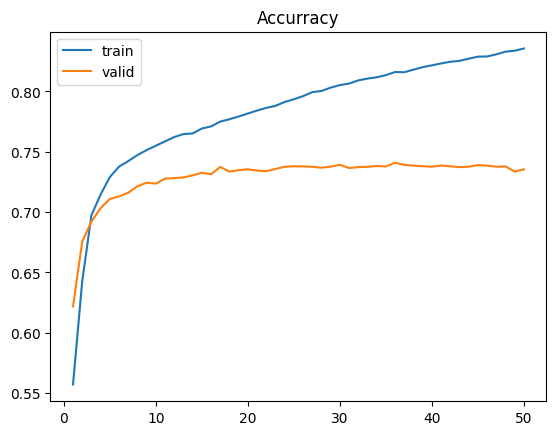

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

epoch_count = range(1, len(hist.history["accuracy"]) + 1)
sns.lineplot(x=epoch_count, y=hist.history["accuracy"], label="train")
sns.lineplot(x=epoch_count, y=hist.history["val_accuracy"], label="valid")
plt.title("Accurracy")
plt.show()

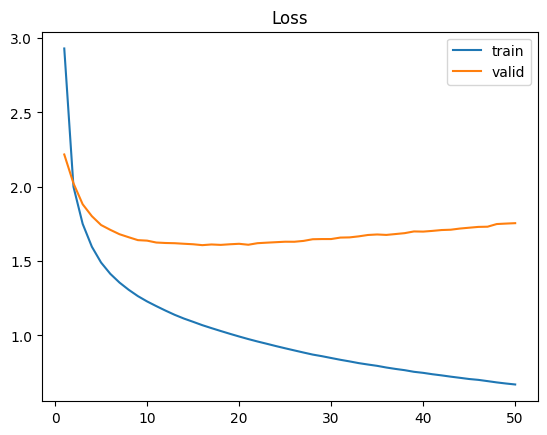

In [129]:
epoch_count = range(1, len(hist.history["loss"]) + 1)
sns.lineplot(x=epoch_count, y=hist.history["loss"], label="train")
sns.lineplot(x=epoch_count, y=hist.history["val_loss"], label="valid")
plt.title("Loss")
plt.show()

### 6 - Inferencia

Para probar el modelo, se definen las siguientes preguntas:

In [130]:
questions = [
    "Do you have any pet",
    "Where are you from",
    "How old are you?",
    "What is your name?",
    "What do yo do",
]

In [131]:
# Diccionarios para ir de índice a palabra:
idx2word_input = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

In [132]:
def chatbot(input_text):
    cleaned_text = clean_text(input_text)
    input_seq = input_tokenizer.texts_to_sequences([cleaned_text])
    input_seq = pad_sequences(input_seq, maxlen=max_input_len, padding="pre")

    # El encoder genera el contexto para el decoder
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs["<sos>"]

    # Se obtiene el índice que finaliza la inferencia
    eos = word2idx_outputs["<eos>"]

    output_sentence = []

    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        word = ""
        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return " ".join(output_sentence)

In [133]:
for question in questions:
    response = chatbot(question)
    print(f"Questions: {question}")
    print(f"Answer: {response}")
    print("\n" + "-" * 30 + "\n")

Questions: Do you have any pet
Answer: yes i have a tiger

------------------------------

Questions: Where are you from
Answer: i am a girl i am a girl

------------------------------

Questions: How old are you?
Answer: i am doing well how are you

------------------------------

Questions: What is your name?
Answer: i like to go to the beach

------------------------------

Questions: What do yo do
Answer: i like to play video games

------------------------------



### Conclusiones

Se recreo la arquitectura Seq2Seq utilizando tanto en el encoder como en el decoder una capa LSTM. Si bien las respuestas del bot no son del todo coherentes, esto se puede atribuir a que el dataset es chico por lo que habría que probar con mas datos. Ademas, para mejorar la predicciones se podría robustecer la arquitectura, por ejemplo apilando capas al encoder (Multi layer) para mejorar el contexto generado. De todas formas para lograr mejoras significativas en las respuestas del bot, se debería pensar en usar arquitecturas mas complejas como los Transformers los cuales captan mejor el contexto y pueden procesar en paralelo.